In [164]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

import gpjax as gpx
import optax as ox
import paramax as px

from non_parametric_pro import ula

from non_parametric_pro.density import ProParameters, pro_logdensity_fn, regularised_score
from non_parametric_pro.ula import parametric_ula
from non_parametric_pro.util import prediction_basis, nlpd_gp, nlpd_pro, crps_gp, crps_pro
from non_parametric_pro.data.uci import load_uci_regression_dataset
from non_parametric_pro.adaptation.parameter_adaptation import parameter_adaptation
from non_parametric_pro.gp import _full_gp_basis
from non_parametric_pro.util import train_val_split


from blackjax.util import run_inference_algorithm

from sklearn.preprocessing import StandardScaler
from scipy import stats

jax.config.update("jax_enable_x64", True)

In [198]:
key = jr.PRNGKey(1)

example = load_uci_regression_dataset("servo", split=2)

scaler_x = StandardScaler()
scaler_y = StandardScaler()

x_train = scaler_x.fit_transform(example.x_train)
y_train = scaler_y.fit_transform(example.y_train)

x_test = scaler_x.transform(example.x_test)
y_test = scaler_y.transform(example.y_test)

# D = 4

# x_train = x_train[:, 0:D]
# x_test = x_test[:, 0:D]

In [234]:
D = x_train.shape[1]

data = gpx.Dataset(X=x_train, y=y_train)
kernel = gpx.kernels.Matern32(lengthscale=jnp.ones((D,)))

prior = gpx.gps.Prior(mean_function=gpx.mean_functions.Zero(), kernel=kernel)
likelihood = gpx.likelihoods.Gaussian(num_datapoints=data.n)
posterior = prior * likelihood

optim = ox.adam(learning_rate=0.1)

gp_posterior, _ = gpx.fit(
    model=posterior,
    objective=lambda p, d: -gpx.objectives.conjugate_mll(p, d),
    train_data=data,
    optim=optim,
    num_iters=200,
    verbose=False,
)

gp_latent_dist = gp_posterior.predict(x_test, train_data=data)
gp_predictive_dist = gp_posterior.likelihood(gp_latent_dist)

gp_predictive_mean = gp_predictive_dist.mean
gp_predictive_std = jnp.sqrt(gp_predictive_dist.variance)

gp_sigma = gp_posterior.likelihood.obs_stddev
gp_kernel = gp_posterior.prior.kernel

print("GP NLPD:", nlpd_gp(y_test, gp_predictive_mean, gp_predictive_std))
print("GP sigma", px.unwrap(gp_sigma))

GP NLPD: 1.681549019147783
GP sigma 0.19828898791973887


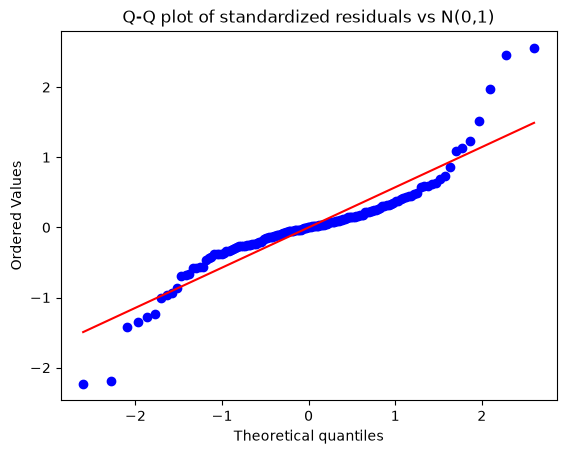

Shapiro-Wilk: 5.30324496818877e-10


In [235]:
gp_latent_dist = gp_posterior.predict(x_train, train_data=data)
gp_predictive_dist = gp_posterior.likelihood(gp_latent_dist)

gp_predictive_mean = gp_predictive_dist.mean
gp_predictive_std = jnp.sqrt(gp_predictive_dist.variance)

residuals = (y_train.squeeze() - gp_predictive_mean) / gp_predictive_std

# Q-Q plot against a standard normal
fig, ax = plt.subplots()
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title("Q-Q plot of standardized residuals vs N(0,1)")
plt.show()

# formal normality tests
print("Shapiro-Wilk:", stats.shapiro(residuals).pvalue)

Running parameter adaptation


<div><progress max="18000" value="18000"></progress> 100.00% [18000/18000 00:00&lt;?]</div>

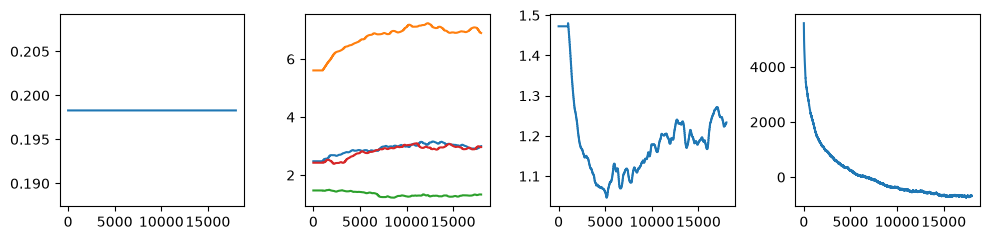

In [246]:
M = x_train.shape[0]
basis, residual_std = _full_gp_basis(gp_posterior, x_train), None
initial_sigma = px.unwrap(gp_sigma)

sigma = gpx.parameters.SigmoidBounded(initial_sigma, low=0.1, high=100.0)

pro_params = ProParameters(
    y=y_train,
    basis=basis,
    step_size=0.0001,
    sigma=sigma,
    alpha=1.0,
    residual_std=residual_std,
    sigma_prior_value=initial_sigma,
    sigma_prior_scale=0.3,
)

J = 30

initial_position = jr.normal(key, (M, J))
num_steps = 18000

adaptation = parameter_adaptation(
    ula,
    pro_logdensity_fn,
    pro_params,
    x_train=x_train,
    initial_kernel=gp_kernel,
    warmup_steps=1000,
    sigma_adapt_every=-1,
    kernel_adapt_every=20,
    objective_fn=regularised_score,
    sigma_optimizer=ox.adam(1e-1),
    progress_bar=True
) 

adaptation_results, adaptation_info = adaptation.run(key, initial_position, num_steps=num_steps)
pro_kernel = jax.tree.map(lambda x: x[-1], adaptation_info.kernel)
pro_params = adaptation_results.parameters
pro_position = adaptation_results.state.position

fig, ax = plt.subplots(1, 4, figsize=(10, 2.5))

ax[0].plot(px.unwrap(adaptation_info.sigma))
ax[1].plot(px.unwrap(adaptation_info.kernel.lengthscale))
ax[2].plot(px.unwrap(adaptation_info.kernel.variance))
ax[3].plot(-adaptation_info.sampler_info.score[10:])
plt.tight_layout()
plt.show()

In [247]:
import blackjax

mala = blackjax.mala(lambda z: pro_logdensity_fn(z, pro_params), 0.0005)
num_steps = 10000

out, info = run_inference_algorithm(
    rng_key=key,
    inference_algorithm=mala,
    num_steps=num_steps,
    initial_position=adaptation_results.state.position,
    progress_bar=True
)

jnp.mean(info[1].acceptance_rate)

<div><progress max="10000" value="10000"></progress> 100.00% [10000/10000 00:00&lt;?]</div>

Array(0.26624167, dtype=float64)

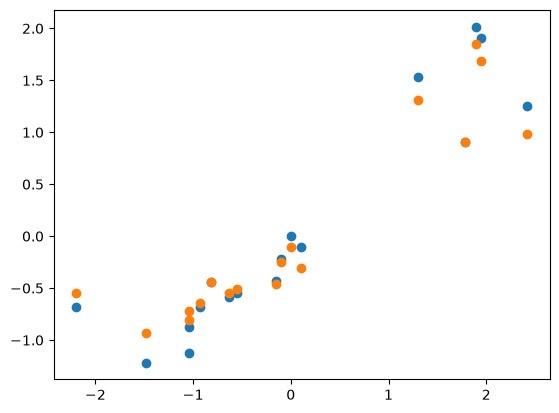

1.681549019147783
1.080772850234905
0.2907047097496258
0.389421624935239


In [248]:
from non_parametric_pro.util import nlpd_gp, nlpd_pro, _as_particle_matrix

x = x_test
y = y_test.squeeze()

burn_ratio = 0.8
thin = 50
burn = int(num_steps * burn_ratio)
particles = info[0].position[burn::thin]

test_basis, test_cov = prediction_basis(pro_kernel, x_train, x, pro_params)

gp_latent_dist = gp_posterior.predict(x, train_data=data)
gp_predictive_dist = gp_posterior.likelihood(gp_latent_dist)

gp_predictive_mean = gp_predictive_dist.mean
gp_predictive_std = jnp.sqrt(gp_predictive_dist.variance)

pro_predictive_mean = jnp.mean(test_basis @ _as_particle_matrix(particles), axis=1)

plt.scatter(y, gp_predictive_mean)
plt.scatter(y, pro_predictive_mean)
plt.show()

print(nlpd_gp(y, gp_predictive_mean, gp_predictive_std))
print(nlpd_pro(y, test_basis, test_cov, particles, parameters=pro_params))

print(jnp.mean((y - gp_predictive_mean) ** 2))
print(jnp.mean((y - pro_predictive_mean) ** 2))

In [148]:
from non_parametric_pro.util import _as_particle_matrix
import paramax

def _nlpd_pro(
    y_test: jax.Array,
    test_basis: jax.Array,
    test_covariance: jax.Array,
    particles: jax.Array,
    *,
    parameters: ProParameters,
    return_per_point: bool = False,
) -> jax.Array:
    """
    Mean negative log predictive density for the PRO GP mixture predictive.

    The predictive is a mixture of Gaussians, one per retained particle:

    .. math::

        p(y^* | \\mathcal{D}) \\approx \\frac{1}{J} \\sum_j
            \\mathcal{N}(y^* \\mid B^* z_j,\\; \\sigma_{\\text{eff}}^2)

    where :math:`\\sigma_{\\text{eff},i}^2 = \\sigma^2 + s_i^2` and
    :math:`s_i = \\sqrt{\\max(k(x^*_i, x^*_i) - \\|B^*_{i,:}\\|^2, 0)}` is the
    sparse-approximation residual at each test point (zero for the full GP).

    Parameters
    ----------
    y_test
        Observed test targets, shape ``(N_test, 1)``.
    test_basis
        Test projection matrix from :func:`prediction_basis`,
        shape ``(N_test, M)`` (inducing) or ``(N_test, N)`` (full GP).
    test_covariance
        Prior kernel matrix at test points ``K(x_*, x_*)``,
        shape ``(N_test, N_test)``, also from :func:`prediction_basis`.
    particles
        Retained latent particles, shape ``(M, J)`` or
        ``(num_steps, M, J)`` (scanned output from
        :func:`blackjax.util.run_inference_algorithm`).
    sigma
        Observation noise standard deviation (plain array or
        ``paramax``-wrapped; unwrapped automatically).

    Returns
    -------
    Scalar NLPD averaged over test points.
    """
    sigma_val = paramax.unwrap(parameters.sigma)
    particle_matrix = _as_particle_matrix(particles)       # (M, J_total)
    projected = test_basis @ particle_matrix               # (N_test, J_total)
    j_total = projected.shape[1]

    # Sparse-approximation residual at test points; 0 for full GP.
    q_diag = jnp.sum(test_basis**2, axis=1)               # (N_test,)
    k_diag = jnp.diag(test_covariance)                    # (N_test,)
    test_residual_std = jnp.sqrt(jnp.maximum(k_diag - q_diag, 0.0))
    sigma_eff = jnp.sqrt(sigma_val**2 + test_residual_std**2).reshape(-1, 1)
    y = y_test.reshape(-1, 1) if y_test.ndim == 1 else y_test   # (N_test, 1)
    a = - jnp.log(sigma_eff)
    b = - 0.5 * ((y - projected) / sigma_eff) ** 2

    return a, b, j_total

def _nlpd_gp(
    y_test: jax.Array,
    predictive_mean: jax.Array,
    predictive_std: jax.Array,
    *,
    return_per_point: bool = False,
) -> jax.Array:
    """
    Mean negative log predictive density for a Gaussian GP predictive.

    Parameters
    ----------
    y_test
        Observed test targets, shape ``(N_test,)`` or ``(N_test, 1)``.
    predictive_mean
        GP predictive mean, same shape as ``y_test``.
    predictive_std
        GP predictive standard deviation (including observation noise),
        same shape as ``y_test``.

    Returns
    -------
    Scalar NLPD averaged over test points.
    """
    y = y_test.squeeze()
    mu = predictive_mean.squeeze()
    std = predictive_std.squeeze()
    a = - jnp.log(std)
    b = - 0.5 * ((y - mu) / std) ** 2
    
    return a, b

c = -0.5 * jnp.log(2 * jnp.pi)

In [89]:
a, b, j_total = _nlpd_pro(y_test, test_basis, test_cov, particles, parameters=pro_params)
d = jnp.log(j_total)

temp = jnp.sum(jnp.exp(a)*jnp.exp(b)*jnp.exp(c), axis=1)
log_p = jnp.log(temp) - d


print(-(jnp.mean(log_p)))

TypeError: sub got incompatible shapes for broadcasting: (54, 1), (482, 36).

In [ ]:
a, b, j_total = _nlpd_pro(y_test, test_basis, test_cov, particles, parameters=pro_params)
d = jnp.log(j_total)

-jnp.mean(jnp.log(jnp.sum(jnp.exp(b), axis=1)) - d)

Array(0.51195138, dtype=float64)

In [ ]:
gp_latent_dist = gp_posterior.predict(x_test, train_data=data)
gp_predictive_dist = gp_posterior.likelihood(gp_latent_dist)

gp_predictive_mean = gp_predictive_dist.mean
gp_predictive_std = jnp.sqrt(gp_predictive_dist.variance)
a, b = _nlpd_gp(y_test, gp_predictive_mean, gp_predictive_std)

temp = jnp.exp(b)

-jnp.mean(jnp.log(temp))

Array(0.37048302, dtype=float64)

In [213]:
a, b, j_total = _nlpd_pro(y_test, test_basis, test_cov, particles, parameters=pro_params)
d = jnp.log(j_total)

temp = jnp.sum(jnp.exp(a)*jnp.exp(b)*jnp.exp(c), axis=1)
log_p = jnp.log(temp) - d

print(-(jnp.mean(log_p)))

0.21775940881138572


In [ ]:
gp_latent_dist = gp_posterior.predict(x_test, train_data=data)
gp_predictive_dist = gp_posterior.likelihood(gp_latent_dist)

gp_predictive_mean = gp_predictive_dist.mean
gp_predictive_std = jnp.sqrt(gp_predictive_dist.variance)
a, b = _nlpd_gp(y_test, gp_predictive_mean, gp_predictive_std)

temp = jnp.exp(a)*jnp.exp(b)*jnp.exp(c)

print(-jnp.mean(jnp.log(temp)))

0.3704830218155804


In [138]:

a, b = _nlpd_pro(y_test, test_basis, test_cov, particles, parameters=pro_params)

temp =  a + b + c

print(-jnp.mean(jnp.log(temp) - jnp.log(J)))

3.300375517784519


nan


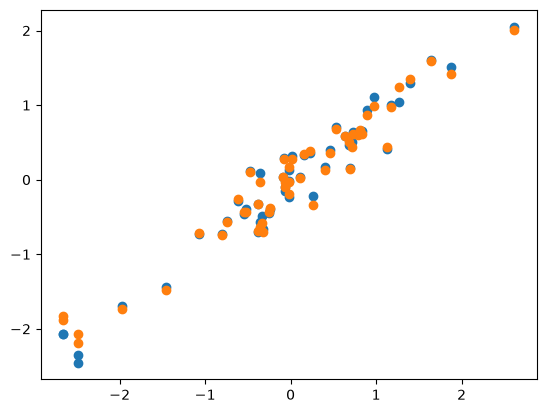

2.089004385952024
2.0112073338956815


In [68]:
plt.scatter(y_test, gp_predictive_mean)
plt.scatter(y_test, pro_predictive_mean)
plt.show()

print(jnp.mean((y_test - gp_predictive_mean) ** 2))
print(jnp.mean((y_test - pro_predictive_mean) ** 2))

In [57]:
print("PRO CRPS:", crps_pro(example.y_test, test_basis, test_cov, out.position, parameters=pro_params))
print("GP CRPS:", crps_gp(example.y_test, gp_predictive_mean, gp_predictive_std))

PRO CRPS: 0.5641621167547514
GP CRPS: 0.5612495172132217


In [ ]:
# algorithm = blackjax.mala(
#     lambda z: pro_logdensity_fn(z, adaptation_params if adapt else pro_params),
#     adaptation_params.step_size if adapt else pro_params.step_size,
# )
